In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.tsa.stattools import adfuller, kpss

In [ ]:
df = pd.read_csv('../data/CORCCACBS.csv')


a = df.groupby(df['date'])['value'].mean().round(2)#.reset_index()
b = pd.to_datetime(df['date'].unique())
df= pd.DataFrame({
    'date':b,
    'value':a.values
})
df = df.set_index('date')

print(df.loc['2011':'2020'])

no time filtering

In [ ]:
plt.plot(df, linewidth=2.0)
plt.ylabel('Delinquency rate')

plt.xlabel('Time')
plt.tight_layout()
plt.show()

In [ ]:
print(df.head())

Finding Rolling mean/std

In [ ]:
period=slice('1990','2023') #take out most recent years to avoid data snooping
df_monthly  = df.resample('ME').mean() #monthly mean
rolling_average = df_monthly[period].rolling(window=12).mean()



fig,ax = plt.subplots(figsize=(8,4))
df_monthly[period].plot(ax=ax,marker='.')
rolling_average.plot(ax=ax, grid=True, legend=False)
plt.show()

lets try a diff 

In [ ]:
dff_diff = df.diff(1)
print(dff_diff.head(10))

## Stationary Tests (to formalize) ADF / KPSS

In [ ]:
adf_p = adfuller(dff_diff.dropna())
print(f'ADF pvalue: {adf_p[1]}')

kpss_p = kpss(dff_diff.dropna(),regression='ct')
print(f'KPSS pvalue: {kpss_p[1]}')


if (adf_p[1] < 0.05) & (kpss_p[1] < 0.05): 
    print('ambigious')

elif (adf_p[1] < 0.05) & (kpss_p[1] > 0.05):
    print('Stationary, awwww yeahhhh')

elif (adf_p[1] > 0.05) & (kpss_p[1] < 0.05):
    print('non-stationary')

else:
    print('trend stationary')


In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Original series
ax1.plot(df, marker='.', linewidth=1.5, label='Original')
ax1.axhline(y=0,  alpha=0.3)
ax1.set_ylabel('Delinquency Rate')
ax1.set_title('Original Series')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Differenced series
ax2.plot(dff_diff, marker='.', linewidth=1.5, color='orange', label='Differenced')
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.3)
ax2.set_ylabel('Difference')
ax2.set_xlabel('Time')
ax2.set_title('Differenced Series (y_t - y_{t-1})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1,ax2) = plt.subplots(2,1,figsize=(10,8))


# ACF plot
plot_acf(df,lags=40,ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')
ax1.set_xlabel('Lag')
ax1.set_ylabel('Correlation')

# PACF plot
plot_pacf(df, lags=40, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF)')
ax2.set_xlabel('Lag')
ax2.set_ylabel('Partial Correlation')

plt.tight_layout()
plt.show()

# Interpreting ACF/PACF
- Important to note that we first confirmed stationarity before conducting the ACF/PACF 


### ACF

- There's a slow decay as we can see, so last quarter strongly predicts today -> Strong AR (up until lag 6 where we had above 50% correlation)
- There's also the some oscillatory pattern, this we can assume to follow the a cycle where recession = rise in defaults and vice versa. but not terribly strong.
- Delinquency rates follow some sort predictable quarterly reporting cycle


### PACF
- big spike at lag 1, then much closer to 0
- another spike (ish) at lag 4, this can be seen as the seasonal AR






Outlier Analysis - lets take a closer look at 2021 to 2023 & what to do...

Based on this article from the Federal Reserve: https://www.federalreserve.gov/econres/notes/feds-notes/a-note-on-recent-dynamics-of-consumer-delinquency-rates-20251124.html


if we look at the whole data as a whole from lets say 2000, world events disaster/epidemic do somewhat happen at a consistent pace... what I put those as a flag?

if we do kind of erase these events, delinquency rates are pretty stuck around 2-4.5%


In [ ]:
threshold_top =4.5 
threshold_bottom = 2

crossed_above = (df.value > threshold_top) & (df.value.shift(1) <= threshold_top)

crossed_below = (df.value < threshold_bottom) & (df.value.shift(1) >= threshold_bottom)

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))

df.plot(ax=ax, linewidth=2, legend=False)
ax.axhline(y=threshold_bottom, linestyle='--', color='r', alpha=0.7)
ax.axhline(y=threshold_top, linestyle='--', color='r', alpha=0.7)


for date in df.index[crossed_above]:
    ax.axvline(x=date, linestyle='--', color='black', alpha=0.6, linewidth=1,label='over')
for date in df.index[crossed_below]:
    ax.axvline(x=date, linestyle='--', color='purple', alpha=0.6, linewidth=1,label="under")

plt.show()

Lets build a baseline using SARIMA

with a AR(1) + seasonal

Should we try adding some features?
- Lagged Values
- rolling mean / volatility
- Crisis indicator


lets split data

In [ ]:
train_set = df.loc[:'2015']
val_set = df.loc['2016':'2019']
test_set = df.loc['2020']

print(train_set.head(2), '\n',  train_set.tail(1))
print(val_set.value.count())
#lets create some features:

train_set_withFE = train_set.copy()

train_set_withFE['crisis_flag'] = ((train_set.value > 4.5) | (train_set.value < 2.0)).astype(int)

train_set_withFE['shift1'] = train_set_withFE['value'].shift(1) #lagged value by 1 

print('HERE',val_set.head(1),val_set.tail(1))


In [100]:
print(train_set.index[:5])
print(train_set.index[-5:])
print(train_set.dtypes)
print(train_set.columns.tolist())
print(train_set.index.freq)

DatetimeIndex(['1985-01-01', '1985-04-01', '1985-07-01', '1985-10-01',
               '1986-01-01'],
              dtype='datetime64[us]', name='date', freq='QS-JAN')
DatetimeIndex(['2014-10-01', '2015-01-01', '2015-04-01', '2015-07-01',
               '2015-10-01'],
              dtype='datetime64[us]', name='date', freq='QS-JAN')
value    float64
dtype: object
['value']
<QuarterBegin: startingMonth=1>


Multi-step without retraining

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


model = SARIMAX(train_set, order=(1,1,0), seasonal_order=(1,0,0,4))
fitted_model = model.fit()


y_pred = fitted_model.forecast(steps=16)
print(y_pred)

Multi-Step with retraining at every step

In [108]:
origin , start_date, end_date = '1985-01-01','2016-01-01','2019-10-01'
time_period = pd.date_range(start_date,end_date,freq='QS')
series = train_set.asfreq('QS')


y_preds = []

for today in time_period.shift(-1):
    window = series.loc[origin:today]

    model = SARIMAX(window,# train on data up to 'today'
                    order=(1,1,0),
                    seasonal_order=(1,0,0,4),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    
    model = model.fit(disp=False, maxiter=200,method='powell')
    y_pred = model.forecast(steps=1).iloc[0]
    y_preds.append(y_pred)

y_preds = pd.Series(y_preds,index=time_period)


In [109]:
print(y_preds)

2016-01-01    2.919773
2016-04-01    2.919773
2016-07-01    2.919773
2016-10-01    2.919773
2017-01-01    2.919773
2017-04-01    2.919773
2017-07-01    2.919773
2017-10-01    2.919773
2018-01-01    2.919773
2018-04-01    2.919773
2018-07-01    2.919773
2018-10-01    2.919773
2019-01-01    2.919773
2019-04-01    2.919773
2019-07-01    2.919773
2019-10-01    2.919773
Freq: QS-JAN, dtype: float64


In [102]:
actuals = val_set.loc[start_date:end_date].iloc[:,0]
common  = y_pred1.index.intersection(actuals.index)

print(f"Predictions: {len(y_pred1)}, Actuals: {len(actuals)}, Matched: {len(common)}")

mae = (y_pred1[common] - actuals[common]).abs().mean()
print(f'MAE: {mae:.4f}')

Predictions: 16, Actuals: 16, Matched: 15
MAE: 0.5809


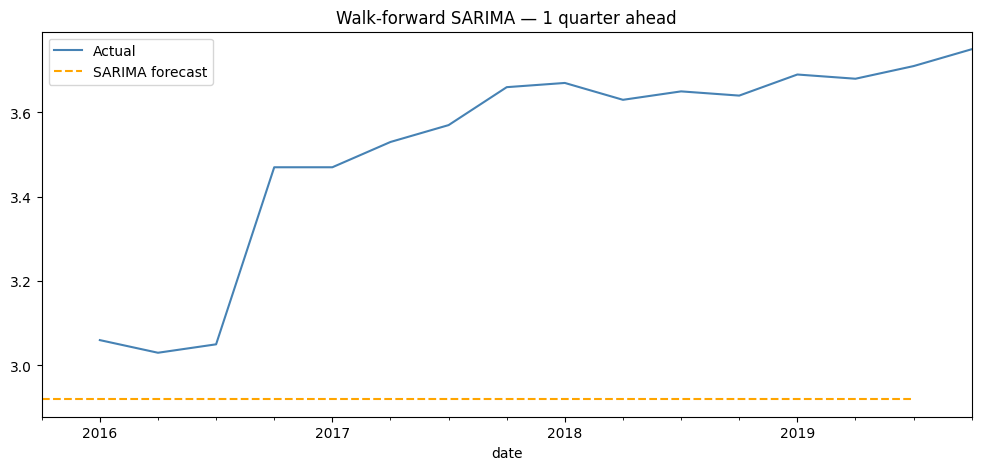

In [103]:
fig, ax = plt.subplots(figsize=(12, 5))
actuals.plot(ax=ax, label='Actual', color='steelblue')
y_pred1.plot(ax=ax, label='SARIMA forecast', color='orange', linestyle='--')
ax.set_title('Walk-forward SARIMA — 1 quarter ahead')
ax.legend()
plt.show()